# XGBoost Classification

## Imports

In [195]:
import pandas as pd

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    average_precision_score,
    ConfusionMatrixDisplay,
    PrecisionRecallDisplay,
    auc,
    balanced_accuracy_score,
    classification_report,
    roc_auc_score,
    roc_curve,
    RocCurveDisplay,
)
from sklearn.model_selection import (
    GridSearchCV,
    StratifiedKFold,
    cross_val_score,
    train_test_split,
)
from sklearn.preprocessing import OneHotEncoder
from xgboost import XGBClassifier, plot_importance
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE
from imblearn.combine import SMOTETomek
from imblearn.under_sampling import RandomUnderSampler
import matplotlib.pyplot as plt


## Load Dataset

In [196]:
# Load and clean dataset
na_values = ["", " ", "NA", "N/A", "NULL"]
data = pd.read_csv("T49.2_Sep2025_1_StGallen.csv", sep=";", na_values=na_values)
display(data.head(30))

threshold = 0.75
data = data.loc[:, data.isnull().mean() < threshold]

binary_mode = True
if binary_mode:
    data = data[data["OUTCOME_3Kat_KHK"] != 1].reset_index(drop=True)

# Auto-convert object columns that look numeric (e.g., 'Alter_0')
object_cols = data.select_dtypes(include="object").columns
numeric_like_cols = []
for col in object_cols:
    cleaned = (
        data[col]
        .astype(str)
        .str.strip()
        .str.replace(r"\s+", "", regex=True)
        .str.replace(",", ".", regex=False)
    )
    numeric_series = pd.to_numeric(cleaned, errors="coerce")
    if numeric_series.notna().mean() > 0.95:
        data[col] = numeric_series
        numeric_like_cols.append(col)

print(
    f"Converted {len(numeric_like_cols)} mostly-numeric columns: {numeric_like_cols}"
)
print(f"Cleaned dataset shape: {data.shape}")


/var/folders/rp/sz_1shj9783116jtrj1kc04m0000gn/T/ipykernel_1371/3515101441.py:3: DtypeWarning: Columns (3,32,119,121,125,129,231,330,342,588) have mixed types. Specify dtype option on import or set low_memory=False.
  data = pd.read_csv("T49.2_Sep2025_1_StGallen.csv", sep=";", na_values=na_values)


,OUTCOME_3Kat_KHK,Alter_0,geschlecht,waist_0,WHR_0,BMI_0,currsmo0,RR_syst_0,RR_diast_0,Pulse_Pressure,...,SMC231l,SMC232l,SMC233l,SMC240l,SMC241l,SMC242l,SMC243l,SMC244l,SMC263l,SMC264l
0,2,"56,9691991786448",0,112,",982456140350877","32,8731097961867",0,130.0,80.0,50.0,...,"9,44","4,38","3,99","14,1","25,8","7,8","3,99","3,99","3,99","3,99"
1,2,"69,4976043805613",0,104,"1,04","30,1102788964583",0,160.0,70.0,90.0,...,"19,8","8,97","7,75","21,9","41,3","20,1","7,35",NaN,"7,45","8,11"
2,2,"72,0492813141684",0,129,",941605839416058","44,7348800491207",0,140.0,90.0,50.0,...,"13,9","4,75","3,99","20,3","52,4","18,6","3,99","3,99","3,99","3,99"
3,2,"70,8145106091718",0,99,",876106194690266","26,2595847484332",0,130.0,90.0,40.0,...,20,"8,73","7,85","25,3","50,7",17,0,NaN,"7,63","9,02"
4,2,"62,1601642710472",1,125,NaN,"42,4366343891054",1,180.0,100.0,80.0,...,"16,9","9,14","8,3","29,5",43,"17,9","8,13",0,"8,4","8,51"
5,2,"73,82340862423",1,97,",989795918367347","26,4462809917355",0,157.0,85.0,72.0,...,"13,1",8,"7,4","15,1","26,4","15,2","7,4","3,89","7,53","8,15"
6,2,"58,4284736481862",1,92,",978723404255319","25,78125",1,130.0,85.0,45.0,...,"16,5","8,61",0,"21,5",48,"20,4",0,NaN,"7,71","9,31"
7,2,"54,5954825462012",0,NaN,NaN,"32,4661454995942",1,140.0,80.0,60.0,...,"18,7","8,84","8,54","28,2","42,7","15,9","8,28",0,"8,44","8,83"
8,2,"76,1724845995893",0,92,",884615384615385","27,2392244832559",0,150.0,110.0,40.0,...,"18,8","8,84","7,71","18,6","40,4","20,8","7,03",0,"7,77","8,3"
9,2,"46,7953456536619",1,81,",931034482758621","20,8209399167162",1,110.0,70.0,40.0,...,"9,25","4,13","3,99","15,7","39,9","14,5","3,99","3,99","3,99","3,99"


Converted 6 mostly-numeric columns: ['Alter_0', 'BMI_0', 'hba1c0', 'TyG_Index_neu', 'crp0', 'Kreat0']
Cleaned dataset shape: (1678, 101)


## Dropping dependant Features

In [197]:
columns_to_drop = ["remnantCholesterol0_corr", "ldl0_mmol", "hdl0_mmol", "triglyc0_mmol", "cholest0_mmol", "LDL_0_apo_B_ratio", "BONE_KAT"]
data = data.drop(columns_to_drop, axis=1)
print(list(data.columns))

['OUTCOME_3Kat_KHK', 'Alter_0', 'geschlecht', 'waist_0', 'WHR_0', 'BMI_0', 'currsmo0', 'RR_syst_0', 'RR_diast_0', 'Pulse_Pressure', 'LDL_0', 'HDL_0', 'triglyc_0', 'cholest_0', 'Lp_a_0', 'apo_A1_gesamt_0', 'apo_B_gesamt_0', 'remnantCholesterol0', 'Glucose_0', 'hba1c0', 'TyG_Index_neu', 'insulm0', 'HOMA_Index_IR_0', 'Delta_Blutglucose', 'diabetes_ADA_final_0', 'FLI', 'THROMB0_gesamt', 'NEUTROPH_gesamt', 'LYMPHOCY_gesamt', 'NLR', 'MONOCYTE_gesamt', 'EOSINOPH_gesamt', 'BASOPHIL_gesamt', 'NEUT_ABS_gesamt', 'LYMP_ABS_gesamt', 'leuko0', 'ery0', 'hb0', 'hct0', 'NATRIUM', 'CALCIUM', 'PHOSPHAT', 'Kalium0', 'GPC4_alle', 'eGFR_CKD_EPI_Kreatinin', 'Kreatinin_Harn_0', 'Albumin_Harn_0', 'ProBNP_0', 'BNP', 'Fibrinogen0', 'crp0', 'Harnstoff0', 'Kreat0', 'Cystatin_gesamt', 'got0', 'gpt0', 'GOT_GPT_Ratio0', 'ggt0', 'aph0', 'ldh0', 'cpk0', 'quick0', 'ptt0', 'tsh0', 'gesew0', 'GESAMT_B', 'GESAMT_T', 'GESAMT_A', 'APPLEAN', 'ANY_OPE', 'ANY_OPO', 'Osteoporos_inkl_Osteopenie_T_Wert_abhängig', 'Osteoporose_T_We

## Preprocessing

In [198]:
# Split data into features and target
X = data.drop("OUTCOME_3Kat_KHK", axis=1)
y = data["OUTCOME_3Kat_KHK"].replace({2: 1})

manual_categorical_candidates = [
    "geschlecht",
    "currsmo0",
    "diabetes_ADA_final_0",
    "ANY_OPE",
    "ANY_OPO",
    "Osteoporos_inkl_Osteopenie_T_Wert_abhängig",
    "Osteoporose_T_Wert_abhängig"
    ]
resolved_categoricals = []
missing_manual = []
for candidate in manual_categorical_candidates:
    match = next((col for col in X.columns if col.lower() == candidate.lower()), None)
    if match:
        resolved_categoricals.append(match)
    else:
        missing_manual.append(candidate)
if missing_manual:
    print(f"Manual categorical columns not found: {missing_manual}")

categorical_features = sorted(dict.fromkeys(resolved_categoricals))

non_cat_object_cols = [
    col for col in X.columns if col not in categorical_features and X[col].dtype == "object"
]
forced_numeric = []
for col in non_cat_object_cols:
    cleaned = (
        X[col]
        .astype(str)
        .str.strip()
        .str.replace(r"\s+", "", regex=True)
        .str.replace(",", ".", regex=False)
    )
    converted = pd.to_numeric(cleaned, errors="coerce")
    X[col] = converted
    forced_numeric.append(col)
if forced_numeric:
    sample = forced_numeric[:5]
    print(
        f"Forced {len(forced_numeric)} object columns to numeric (sample: {sample})"
    )


numerical_features = [col for col in X.columns if col not in categorical_features]


print(f"Categorical features ({len(categorical_features)}): {categorical_features}")
print(f"Numerical features ({len(numerical_features)}): sample -> {numerical_features[:5]}")

# Split data into train and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

cat_pre = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("ohe", OneHotEncoder(handle_unknown="ignore")),
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("cat", cat_pre, categorical_features),
        ("num", SimpleImputer(strategy="median"), numerical_features),
    ]
)


Forced 53 object columns to numeric (sample: ['waist_0', 'WHR_0', 'Lp_a_0', 'insulm0', 'HOMA_Index_IR_0'])
Categorical features (7): ['ANY_OPE', 'ANY_OPO', 'Osteoporos_inkl_Osteopenie_T_Wert_abhängig', 'Osteoporose_T_Wert_abhängig', 'currsmo0', 'diabetes_ADA_final_0', 'geschlecht']
Numerical features (86): sample -> ['Alter_0', 'waist_0', 'WHR_0', 'BMI_0', 'RR_syst_0']


## Build Pipeline

In [199]:
xgb_params = {
    "tree_method": "hist",
    "n_estimators": 200,        # BEST PARAM
    "learning_rate": 0.03,      # BEST PARAM
    "max_depth": 6,             # BEST PARAM
    "subsample": 0.7,           # BEST PARAM
    "colsample_bytree": 0.7,    # BEST PARAM
    "random_state": 42,
    "eval_metric": "logloss",
    "n_jobs": -1,
}

pipeline = Pipeline(
    [
        ("preprocessor", preprocessor),
        ("smote", SMOTE(random_state=42)),
        ("classifier", XGBClassifier(**xgb_params)),
    ]
)


#CV and training
# Perform 5-fold cross-validation

cv_scores = cross_val_score(pipeline, X_train, y_train, cv=5)

# Fit the model on the training data
pipeline.fit(X_train, y_train)

# Predict on the test set
y_pred = pipeline.predict(X_test)


In [ ]:
# Compare oversampling and undersampling strategies
sampling_strategies = {
    "SMOTE (oversampling baseline)": lambda: SMOTE(random_state=42),
    "SMOTETomek (hybrid)": lambda: SMOTETomek(random_state=42),
    "RandomUnderSampler": lambda: RandomUnderSampler(random_state=42),
}

sampling_results = []
fitted_sampling_pipelines = {}

for name, sampler_factory in sampling_strategies.items():
    sampling_pipeline = Pipeline(
        steps=[
            ("preprocessor", preprocessor),
            ("sampler", sampler_factory()),
            ("classifier", XGBClassifier(**xgb_params)),
        ]
    )

    cv_scores = cross_val_score(
        sampling_pipeline,
        X_train,
        y_train,
        cv=5,
        scoring="balanced_accuracy",
        n_jobs=-1,
    )

    sampling_pipeline.fit(X_train, y_train)
    y_pred_sample = sampling_pipeline.predict(X_test)
    y_prob_sample = sampling_pipeline.predict_proba(X_test)[:, 1]

    sampling_results.append(
        {
            "sampler": name,
            "cv_balanced_accuracy": cv_scores.mean(),
            "test_balanced_accuracy": balanced_accuracy_score(y_test, y_pred_sample),
            "test_roc_auc": roc_auc_score(y_test, y_prob_sample),
            "test_avg_precision": average_precision_score(y_test, y_prob_sample),
        }
    )
    fitted_sampling_pipelines[name] = sampling_pipeline
    print(
        f"{name} | CV balanced acc: {cv_scores.mean():.4f} | Test balanced acc: {balanced_accuracy_score(y_test, y_pred_sample):.4f}"
    )

sampling_results_df = (
    pd.DataFrame(sampling_results)
    .sort_values(by="test_balanced_accuracy", ascending=False)
    .reset_index(drop=True)
)
display(sampling_results_df)

best_sampling = sampling_results_df.iloc[0]
best_sampling_pipeline = fitted_sampling_pipelines[best_sampling["sampler"]]
print(
    f"Best sampler on test set: {best_sampling['sampler']} "
    f"(balanced acc={best_sampling['test_balanced_accuracy']:.4f}, "
    f"ROC AUC={best_sampling['test_roc_auc']:.4f})"
)


## Evaluation

In [200]:

# Classification Report
report = classification_report(y_test, y_pred, target_names=["No Stenosis", "Significant Stenosis"])

# Balanced Accuracy
balanced_acc = balanced_accuracy_score(y_test, y_pred)

print(f"Mean Cross-Validation Accuracy: {cv_scores.mean():.4f}")
print(f"Balanced Accuracy: {balanced_acc:.4f}")
print("\nClassification Report:")
print(report)


Mean Cross-Validation Accuracy: 0.7951
Balanced Accuracy: 0.6988

Classification Report:
                      precision    recall  f1-score   support

         No Stenosis       0.48      0.51      0.50        57
Significant Stenosis       0.90      0.89      0.89       279

            accuracy                           0.82       336
           macro avg       0.69      0.70      0.69       336
        weighted avg       0.83      0.82      0.83       336



## Visualization Binary

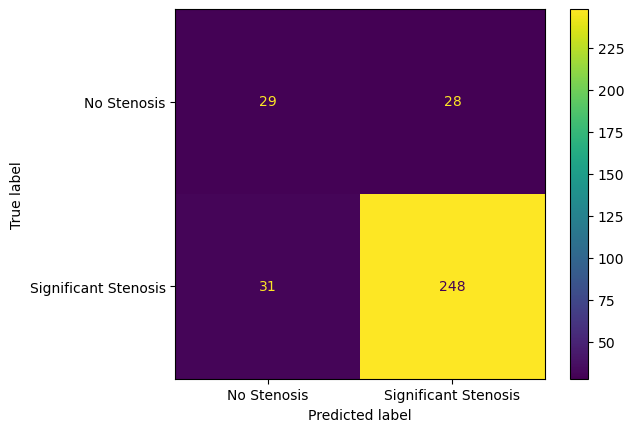

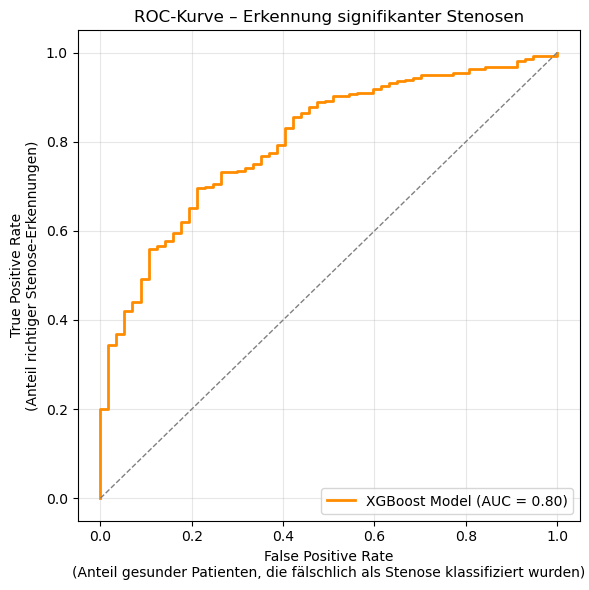

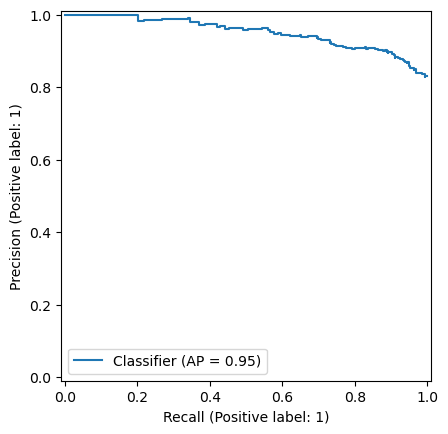

In [201]:

# Get preprocessed test data
X_test_prepared = pipeline.named_steps["preprocessor"].transform(X_test)
y_pred = pipeline.named_steps["classifier"].predict(X_test_prepared)

# Confusion Matrix
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, display_labels=["No Stenosis", "Significant Stenosis"])

# ROC Curve
y_prob = pipeline.named_steps["classifier"].predict_proba(X_test_prepared)[:, 1]

# Calculate ROC curve and AUC
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

# Plot
plt.figure(figsize=(6, 6))
plt.plot(fpr, tpr, color="darkorange", lw=2,
         label=f"XGBoost Model (AUC = {roc_auc:.2f})")
plt.plot([0, 1], [0, 1], color="gray", lw=1, linestyle="--")

# Achsenbeschriftungen und Titel
plt.xlabel("False Positive Rate\n(Anteil gesunder Patienten, die fälschlich als Stenose klassifiziert wurden)")
plt.ylabel("True Positive Rate\n(Anteil richtiger Stenose-Erkennungen)")
plt.title("ROC-Kurve – Erkennung signifikanter Stenosen")
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Precision–Recall Curve
PrecisionRecallDisplay.from_predictions(y_test, pipeline.named_steps["classifier"].predict_proba(X_test_prepared)[:, 1])


# Feature Importance

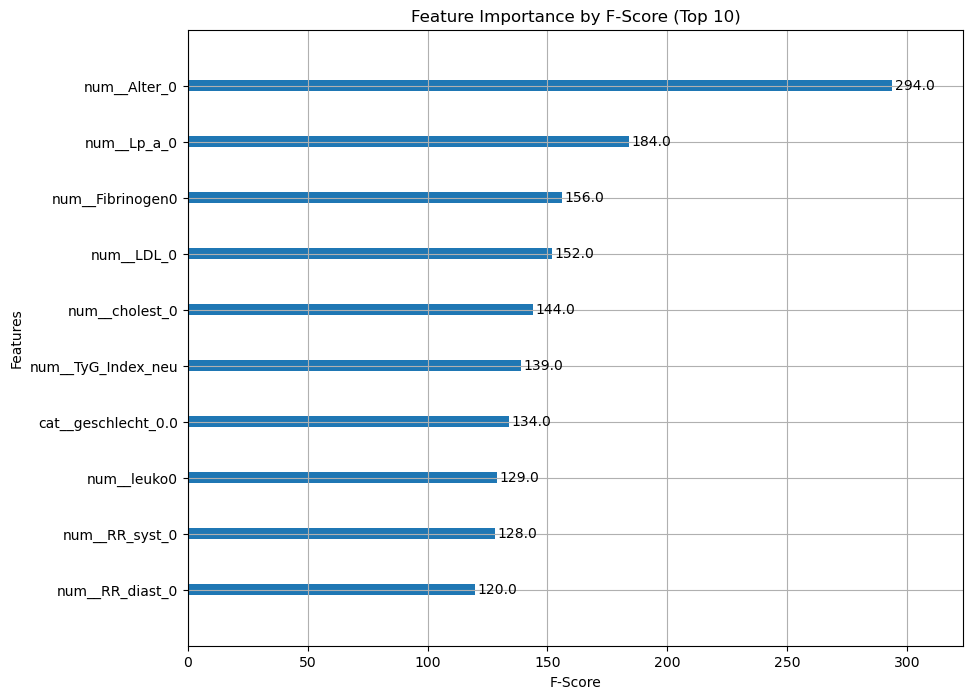

In [202]:
# Find the top 10 important features using XGBoost's plot_importance

# 1. Get the final feature names
feature_names_out = pipeline.named_steps['preprocessor'].get_feature_names_out()

# 2. Extract the trained scikit-learn wrapper
xgb_model = pipeline.named_steps['classifier']

# 3. CRITICAL: Get the underlying Booster object
booster = xgb_model.get_booster()

# 4. CRITICAL: Set the feature names on the Booster object
booster.feature_names = list(feature_names_out)

# 5. Plot the importance using the Booster
fig, ax = plt.subplots(1, 1, figsize=(10, 8))
plot_importance(
    booster,
    ax=ax,
    importance_type='weight',
    xlabel='F-Score',
    max_num_features=10
)
ax.set_title("Feature Importance by F-Score (Top 10)")
plt.show()

--- Worst 10 Features by F-Score Importance ---
                                              Feature  Importance
3                                    cat__ANY_OPO_1.0         1.0
5   cat__Osteoporos_inkl_Osteopenie_T_Wert_abhängi...         1.0
2                                    cat__ANY_OPO_0.0         2.0
1                                    cat__ANY_OPE_1.0         7.0
4   cat__Osteoporos_inkl_Osteopenie_T_Wert_abhängi...        13.0
7                                   cat__currsmo0_1.0        13.0
78                                    num__Cer_d18_16        13.0
80                                  num__Cer_d18_24_0        14.0
75                                      num__GESAMT_A        16.0
89                                         num__CERT2        16.0


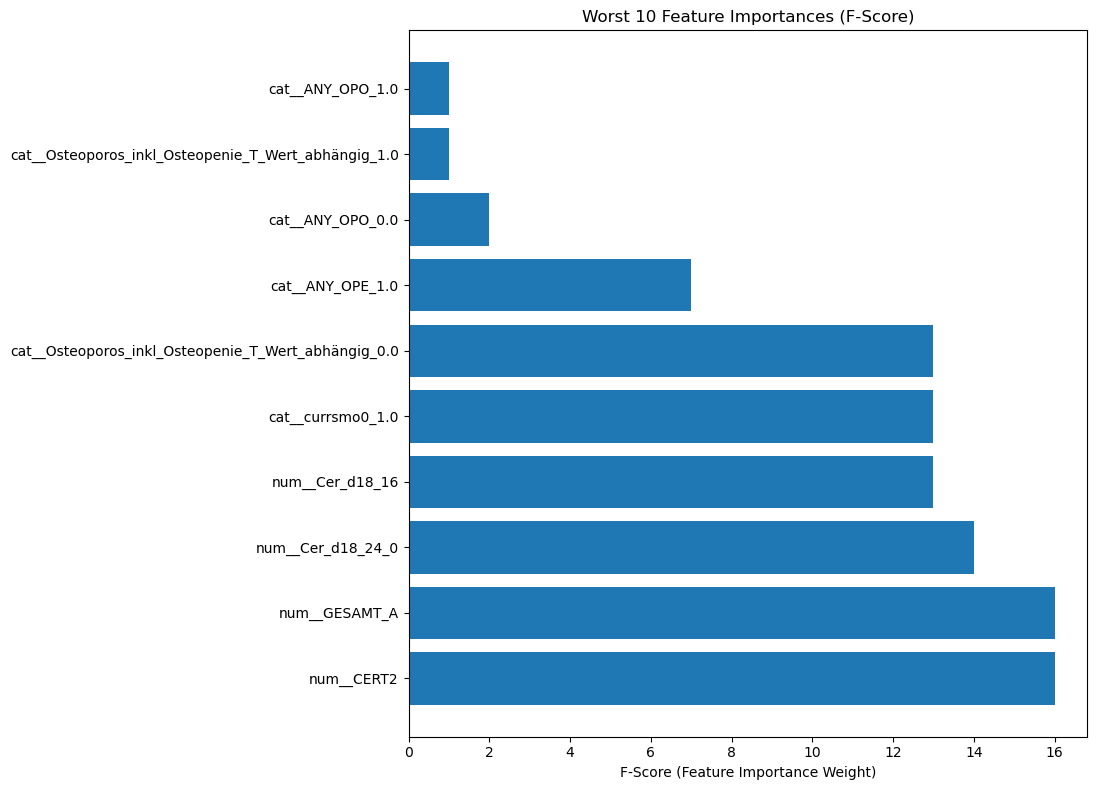

In [203]:
ig, (ax_top, ax_worst) = plt.subplots(1, 2, figsize=(18, 8)) 

# You must also define ax_top even if you don't plot on it, 
# or else you will get an index error later when you try to access ax_worst.
# Let's use a dummy plot on ax_top for now to keep the array structure intact.
ax_top.set_visible(False) # Hide the first axis if you only want to see the second one

# --- Your code snippet starts here ---
importance_dict = booster.get_score(importance_type='weight')
importance_df = pd.DataFrame(
    list(importance_dict.items()),
    columns=['Feature', 'Importance']
).sort_values(by='Importance', ascending=True)

worst_10_features = importance_df.head(10)

print("--- Worst 10 Features by F-Score Importance ---")
print(worst_10_features)

# Plot Worst 10 on the second subplot
ax_worst.barh(worst_10_features['Feature'], worst_10_features['Importance'])
ax_worst.set_title("Worst 10 Feature Importances (F-Score)")
ax_worst.set_xlabel("F-Score (Feature Importance Weight)")
ax_worst.invert_yaxis()

plt.tight_layout()
plt.show()

In [204]:
# Inspect how each feature is treated
feature_treatment = pd.DataFrame({
    'feature': X.columns,
    'pandas_dtype': X.dtypes.astype(str),
    'treated_as': [
        'categorical' if col in categorical_features else (
            'numerical' if col in numerical_features else 'other'
        )
        for col in X.columns
    ]
})
display(feature_treatment.sort_values(['treated_as', 'feature']).reset_index(drop=True))
print(f"Categorical features ({len(categorical_features)}): {categorical_features}")
print(f"Numerical features ({len(numerical_features)}): {numerical_features}")


,feature,pandas_dtype,treated_as
0,ANY_OPE,float64,categorical
1,ANY_OPO,float64,categorical
2,Osteoporos_inkl_Osteopenie_T_Wert_abhängig,float64,categorical
3,Osteoporose_T_Wert_abhängig,float64,categorical
4,currsmo0,int64,categorical
...,...,...,...
88,quick0,float64,numerical
89,remnantCholesterol0,float64,numerical
90,triglyc_0,float64,numerical
91,tsh0,float64,numerical


Categorical features (7): ['ANY_OPE', 'ANY_OPO', 'Osteoporos_inkl_Osteopenie_T_Wert_abhängig', 'Osteoporose_T_Wert_abhängig', 'currsmo0', 'diabetes_ADA_final_0', 'geschlecht']
Numerical features (86): ['Alter_0', 'waist_0', 'WHR_0', 'BMI_0', 'RR_syst_0', 'RR_diast_0', 'Pulse_Pressure', 'LDL_0', 'HDL_0', 'triglyc_0', 'cholest_0', 'Lp_a_0', 'apo_A1_gesamt_0', 'apo_B_gesamt_0', 'remnantCholesterol0', 'Glucose_0', 'hba1c0', 'TyG_Index_neu', 'insulm0', 'HOMA_Index_IR_0', 'Delta_Blutglucose', 'FLI', 'THROMB0_gesamt', 'NEUTROPH_gesamt', 'LYMPHOCY_gesamt', 'NLR', 'MONOCYTE_gesamt', 'EOSINOPH_gesamt', 'BASOPHIL_gesamt', 'NEUT_ABS_gesamt', 'LYMP_ABS_gesamt', 'leuko0', 'ery0', 'hb0', 'hct0', 'NATRIUM', 'CALCIUM', 'PHOSPHAT', 'Kalium0', 'GPC4_alle', 'eGFR_CKD_EPI_Kreatinin', 'Kreatinin_Harn_0', 'Albumin_Harn_0', 'ProBNP_0', 'BNP', 'Fibrinogen0', 'crp0', 'Harnstoff0', 'Kreat0', 'Cystatin_gesamt', 'got0', 'gpt0', 'GOT_GPT_Ratio0', 'ggt0', 'aph0', 'ldh0', 'cpk0', 'quick0', 'ptt0', 'tsh0', 'gesew0', '

## Gridsearch

In [205]:
# Hyperparameter search
param_grid = {
    'classifier__n_estimators': [200, 400, 600],
    'classifier__max_depth': [4, 6, 8],
    'classifier__learning_rate': [0.05, 0.1],
    'classifier__subsample': [0.7, 0.85],
    'classifier__colsample_bytree': [0.7, 0.85],
}

cv_strategy = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
grid_search = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    scoring='balanced_accuracy',
    cv=cv_strategy,
    n_jobs=-1,
    verbose=1,
)
grid_search.fit(X_train, y_train)

print(f"Best balanced accuracy (CV): {grid_search.best_score_:.4f}")
print('Best params:')
for k, v in grid_search.best_params_.items():
    print(f'  {k}: {v}')

best_model = grid_search.best_estimator_
y_pred_gs = best_model.predict(X_test)
balanced_acc_gs = balanced_accuracy_score(y_test, y_pred_gs)
print(f"Test balanced accuracy (best model): {balanced_acc_gs:.4f}")


Fitting 3 folds for each of 72 candidates, totalling 216 fits
Best balanced accuracy (CV): 0.6947
Best params:
  classifier__colsample_bytree: 0.85
  classifier__learning_rate: 0.05
  classifier__max_depth: 6
  classifier__n_estimators: 400
  classifier__subsample: 0.85
Test balanced accuracy (best model): 0.6657


In [206]:
# Extrahiere alle für das Modell genutzten Daten der kategorialen Features
if categorical_features:
    categorical_data_used = X[categorical_features].copy()
    print(f'Kategorische Features: {len(categorical_features)} -> {categorical_features}')
    print('Form des kategorialen Datensatzes:', categorical_data_used.shape)
    display(categorical_data_used)
else:
    print('Keine kategorialen Features für dieses Modell gefunden.')

Kategorische Features: 7 -> ['ANY_OPE', 'ANY_OPO', 'Osteoporos_inkl_Osteopenie_T_Wert_abhängig', 'Osteoporose_T_Wert_abhängig', 'currsmo0', 'diabetes_ADA_final_0', 'geschlecht']
Form des kategorialen Datensatzes: (1678, 7)


,ANY_OPE,ANY_OPO,Osteoporos_inkl_Osteopenie_T_Wert_abhängig,Osteoporose_T_Wert_abhängig,currsmo0,diabetes_ADA_final_0,geschlecht
0,0.0,0.0,0.0,0.0,0,1,0
1,0.0,0.0,0.0,0.0,0,0,0
2,1.0,0.0,0.0,0.0,0,1,0
3,0.0,0.0,0.0,0.0,0,1,0
4,1.0,0.0,1.0,0.0,1,1,1
...,...,...,...,...,...,...,...
1673,NaN,NaN,NaN,NaN,0,0,1
1674,NaN,NaN,NaN,NaN,0,0,0
1675,NaN,NaN,NaN,NaN,0,0,0
1676,NaN,NaN,NaN,NaN,0,1,0


In [207]:
# Kompaktere Grid Search, geeignet für lokale Hardware
param_grid = {
    'classifier__n_estimators': [200, 400],
    'classifier__learning_rate': [0.03, 0.06],
    'classifier__max_depth': [4, 6],
    'classifier__min_child_weight': [1, 3],
    'classifier__gamma': [0, 0.2],
    'classifier__subsample': [0.7, 0.9],
    'classifier__colsample_bytree': [0.7, 0.9],
    'classifier__reg_lambda': [1, 5],
}

cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

grid_search = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    scoring='balanced_accuracy',
    cv=cv_strategy,
    n_jobs=-1,
    verbose=2,
)

grid_search.fit(X_train, y_train)

print(f"Best CV balanced accuracy: {grid_search.best_score_:.4f}")
print("Best params:")
for k, v in grid_search.best_params_.items():
    print(f"  {k}: {v}")

best_grid_model = grid_search.best_estimator_
y_pred_grid = best_grid_model.predict(X_test)
y_prob_grid = best_grid_model.predict_proba(X_test)[:, 1]
print(f"Test balanced accuracy (grid): {balanced_accuracy_score(y_test, y_pred_grid):.4f}")
print(f"Test ROC AUC (grid): {roc_auc_score(y_test, y_prob_grid):.4f}")
print(f"Test average precision (grid): {average_precision_score(y_test, y_prob_grid):.4f}")

Fitting 5 folds for each of 256 candidates, totalling 1280 fits
[CV] END classifier__colsample_bytree=0.7, classifier__gamma=0, classifier__learning_rate=0.03, classifier__max_depth=4, classifier__min_child_weight=1, classifier__n_estimators=200, classifier__reg_lambda=1, classifier__subsample=0.7; total time=   0.2s
[CV] END classifier__colsample_bytree=0.7, classifier__gamma=0, classifier__learning_rate=0.03, classifier__max_depth=4, classifier__min_child_weight=1, classifier__n_estimators=200, classifier__reg_lambda=1, classifier__subsample=0.7; total time=   0.2s
[CV] END classifier__colsample_bytree=0.7, classifier__gamma=0, classifier__learning_rate=0.03, classifier__max_depth=4, classifier__min_child_weight=1, classifier__n_estimators=200, classifier__reg_lambda=1, classifier__subsample=0.9; total time=   0.2s
[CV] END classifier__colsample_bytree=0.7, classifier__gamma=0, classifier__learning_rate=0.03, classifier__max_depth=4, classifier__min_child_weight=1, classifier__n_esti

/opt/anaconda3/lib/python3.12/site-packages/joblib/externals/loky/process_executor.py:752: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


[CV] END classifier__colsample_bytree=0.7, classifier__gamma=0, classifier__learning_rate=0.06, classifier__max_depth=6, classifier__min_child_weight=1, classifier__n_estimators=400, classifier__reg_lambda=1, classifier__subsample=0.9; total time=   0.8s
[CV] END classifier__colsample_bytree=0.7, classifier__gamma=0, classifier__learning_rate=0.06, classifier__max_depth=6, classifier__min_child_weight=1, classifier__n_estimators=400, classifier__reg_lambda=1, classifier__subsample=0.9; total time=   0.8s
[CV] END classifier__colsample_bytree=0.7, classifier__gamma=0, classifier__learning_rate=0.06, classifier__max_depth=6, classifier__min_child_weight=1, classifier__n_estimators=400, classifier__reg_lambda=1, classifier__subsample=0.9; total time=   0.7s
[CV] END classifier__colsample_bytree=0.7, classifier__gamma=0, classifier__learning_rate=0.06, classifier__max_depth=6, classifier__min_child_weight=1, classifier__n_estimators=400, classifier__reg_lambda=1, classifier__subsample=0.9;

In [208]:
# Randomized Search mit breiterem Parameterraum
from scipy.stats import uniform, randint

param_distributions = {
    'classifier__n_estimators': randint(200, 1200),
    'classifier__learning_rate': uniform(0.01, 0.15),
    'classifier__max_depth': randint(3, 11),
    'classifier__min_child_weight': randint(1, 8),
    'classifier__gamma': uniform(0, 0.4),
    'classifier__subsample': uniform(0.5, 0.5),
    'classifier__colsample_bytree': uniform(0.5, 0.5),
    'classifier__reg_lambda': uniform(0.5, 10),
    'classifier__reg_alpha': uniform(0, 1),
}

random_search = RandomizedSearchCV(
    estimator=pipeline,
    param_distributions=param_distributions,
    n_iter=40,
    scoring='balanced_accuracy',
    cv=cv_strategy,
    n_jobs=-1,
    verbose=2,
    random_state=42,
)

random_search.fit(X_train, y_train)

print(f"Best CV balanced accuracy (randomized): {random_search.best_score_:.4f}")
print("Best params:")
for k, v in random_search.best_params_.items():
    print(f"  {k}: {v}")

best_random_model = random_search.best_estimator_
y_pred_random = best_random_model.predict(X_test)
y_prob_random = best_random_model.predict_proba(X_test)[:, 1]
print(f"Test balanced accuracy (randomized): {balanced_accuracy_score(y_test, y_pred_random):.4f}")
print(f"Test ROC AUC (randomized): {roc_auc_score(y_test, y_prob_random):.4f}")
print(f"Test average precision (randomized): {average_precision_score(y_test, y_prob_random):.4f}")

NameError: name 'RandomizedSearchCV' is not defined